In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
from pybib.calc import *
#!pip freeze > requirements.txt

In [2]:
file_path = './polblogs/polblogs.gml'
G = load_gml(file_path)
G = apagar_nos_com_grau_zero(G)

In [4]:
categorias = np.array([G.nodes[i]['weight'] for i in G.nodes])

In [9]:
w = np.unique(categorias,return_counts=True)[1]
w = w/np.sum(w)
np.savetxt('./input/polblogs/faixas.txt',w,fmt = '%f')

In [37]:
nx.attribute_assortativity_coefficient(G,'weight')

0.8229242280560486

In [33]:
nx.transitivity(G),nx.assortativity(G)

TypeError: 'module' object is not callable

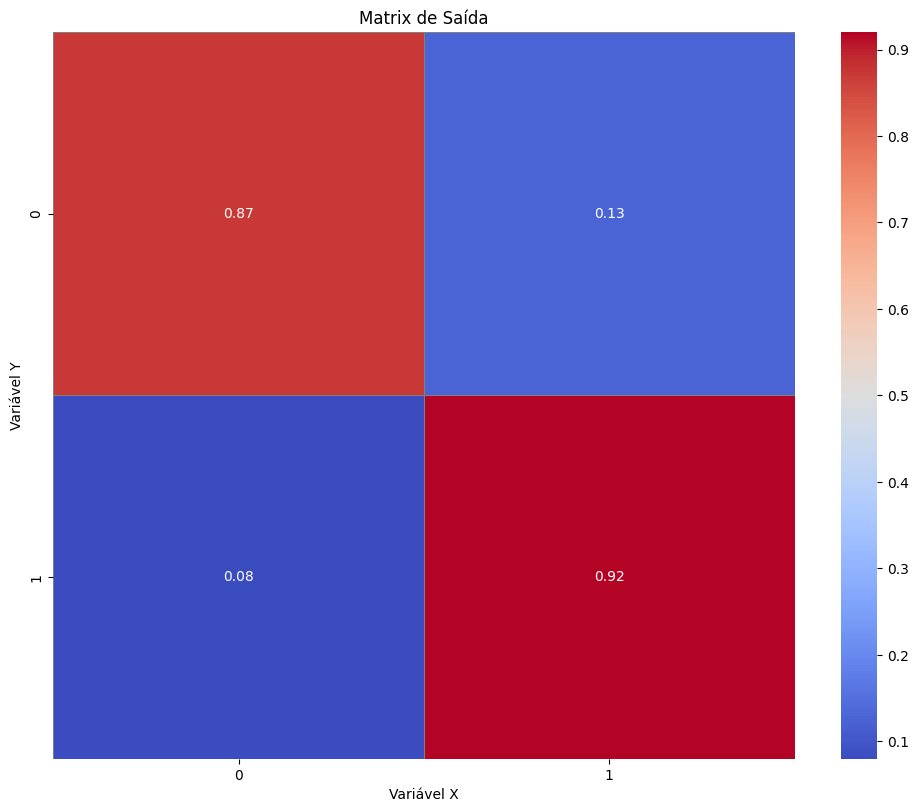

In [13]:
plt.figure(figsize=(10, 8))
Matrix = generate_distribution_byfaixas(df_out,categorias)

heatmap = sns.heatmap(Matrix, 
                      annot=True,          # Adiciona os valores em cada célula
                      fmt=".2f",           # Formato dos números exibidos
                      cmap="coolwarm",      # Paleta de cores que vai do azul ao vermelho
                      #cbar_kws={'label': 'Escala de valores'},  # Legenda da barra de cores
                      linewidths=0.5,       # Largura das linhas entre as células
                      linecolor='gray')     # Cor das linhas

# Título e rótulos
plt.xlabel("Variável X")
plt.ylabel("Variável Y")

# Ajustes finais
plt.tight_layout()
plt.title("Matrix de Saída")
np.savetxt('./input/multi_probability_out.txt',Matrix,fmt = '%f')
# Exibir o gráfico
plt.show()

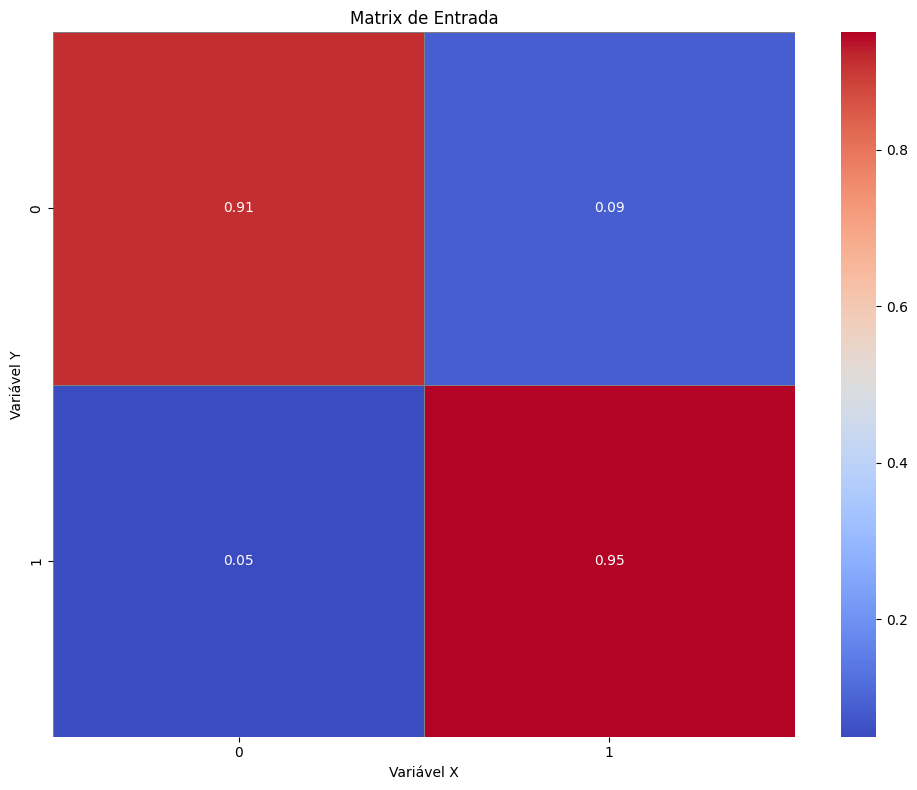

In [14]:
plt.figure(figsize=(10, 8))
Matrix = generate_distribution_byfaixas(df_in,categorias)
heatmap = sns.heatmap(Matrix, 
                      annot=True,          # Adiciona os valores em cada célula
                      fmt=".2f",           # Formato dos números exibidos
                      cmap="coolwarm",      # Paleta de cores que vai do azul ao vermelho
                      #cbar_kws={'label': 'Escala de valores'},  # Legenda da barra de cores
                      linewidths=0.5,       # Largura das linhas entre as células
                      linecolor='gray')     # Cor das linhas

# Título e rótulos
plt.xlabel("Variável X")
plt.ylabel("Variável Y")

# Ajustes finais
# É mais provável dado um espectro político citar o outro espectro do que o outro espectro citar você.
plt.title("Matrix de Entrada")
plt.tight_layout()
np.savetxt('./input/multi_probability_in.txt',Matrix,fmt = '%f')
# Exibir o gráfico
plt.show()

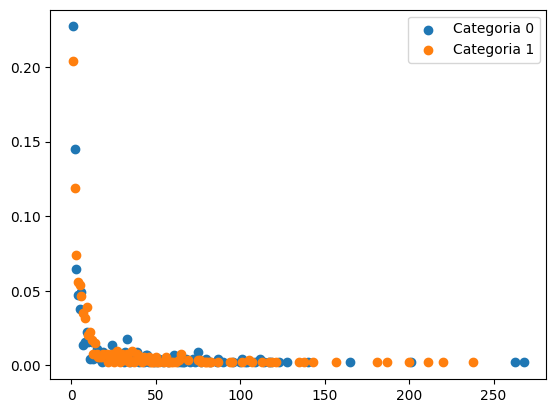

In [6]:
gin,gout = calcular_graus_por_categoria(G,0)
arr,hist = histogram(gin[gin > 0])
plt.scatter(arr,hist/np.sum(hist),label = 'Categoria 0')
gin,gout = calcular_graus_por_categoria(G,1)
arr,hist = histogram(gin[gin > 0])
plt.scatter(arr,hist/np.sum(hist),label = 'Categoria 1')
#arr,hist = histogram(gout)
#plt.scatter(arr,hist,label = 'Degree out')
plt.legend()
plt.show()

In [16]:
def generate_distribuition(G,categoria):
    gin,gout = calcular_graus_por_categoria(G,categoria)
    gin,p = histogram(gin[gin > 0])
    p = p/np.sum(p)
    m = 268

    arr = np.arange(1,m+1)
    prob = np.ones(len(arr))*-1
    p = np.cumsum(p)
    for i,p in zip(gin,p):
        prob[i-1] = p
    P = np.array([arr,prob]).T

    np.savetxt(f'./input/distribution_{categoria}_in.txt',P,fmt = "%d %f")
    gout,p = histogram(gout[gout > 0])
    p = p/np.sum(p)
    arr = np.arange(1,m+1)
    prob = np.ones(len(arr))*-1
    p = np.cumsum(p)
    for i,p in zip(gout,p):
        prob[i-1] = p
    P = np.array([arr,prob]).T

    np.savetxt(f'./input/distribution_{categoria}_out.txt',P,fmt = "%d %f")

In [17]:
generate_distribuition(G,0)
generate_distribuition(G,1)

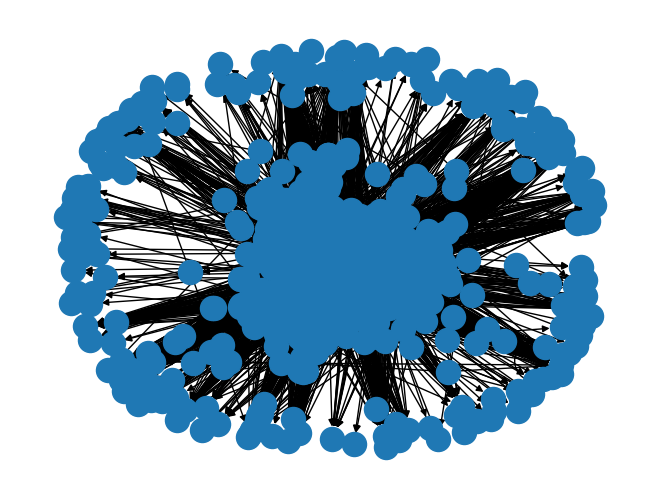

In [89]:
nx.draw(G)